# Task 0:

## Imports

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Hyperparameters

In [ ]:
BASE_DIRECTORY = os.path.dirname(os.getcwd())
PATH_FISH_0 = os.path.join(BASE_DIRECTORY, "1_data", "Marelec_sample", "0", "2021-04-28-02-55-19-160-Sei-Sei-80.000.bmp")
PATH_FISH_1 = os.path.join(BASE_DIRECTORY, "1_data", "Marelec_sample", "1", "2021-04-27-00-45-33-488-Sei-Hyse-86.000.bmp")

PATH_FOLDER_0 = "../1_data/Marelec_sample/0/"
PATH_FOLDER_1 = "../1_data/Marelec_sample/1/"
PATH_FOLDER_2 = "../1_data/Marelec_sample/2/"
TEST_SET = [PATH_FOLDER_0, PATH_FOLDER_1, PATH_FOLDER_2]

LOWER_COLOR_FISH = np.array([140, 100, 100])
UPPER_COLOR_FISH = np.array([179, 255, 255])

# Task 1: Fish Segmentation

In [50]:
img_background = cv2.imread(PATH_FISH_0)
img_fish = cv2.cvtColor(cv2.imread(PATH_FISH_1), cv2.COLOR_BGR2RGB)

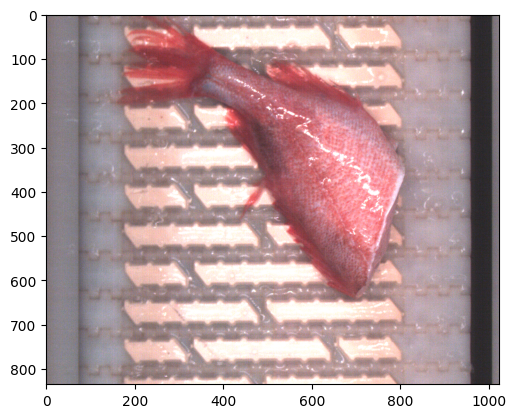

In [51]:
plt.imshow(img_fish)

## First method: Color Segmentation

In [39]:
def nothing(x):
    pass

# 1. Laad je afbeelding
# Gebruik het pad dat we eerder hebben hersteld!
image = cv2.imread("../1_data/Marelec_sample/1/2021-04-27-00-45-33-488-Sei-Hyse-86.000.bmp")

# Check of de afbeelding geladen is om de bekende TypeError te voorkomen
if image is None:
    print("Check je pad! Afbeelding niet gevonden.")
else:
    # Maak een venster voor de sliders
    cv2.namedWindow('HSV Tuner', cv2.WINDOW_NORMAL)
    cv2.resizeWindow('HSV Tuner', 600, 300)

    # Maak trackbars voor de onderste en bovenste grenzen
    cv2.createTrackbar('Low H', 'HSV Tuner', 0, 179, nothing)
    cv2.createTrackbar('Low S', 'HSV Tuner', 0, 255, nothing)
    cv2.createTrackbar('Low V', 'HSV Tuner', 0, 255, nothing)
    cv2.createTrackbar('High H', 'HSV Tuner', 179, 179, nothing)
    cv2.createTrackbar('High S', 'HSV Tuner', 255, 255, nothing)
    cv2.createTrackbar('High V', 'HSV Tuner', 255, 255, nothing)

    while True:
        # Lees de huidige standen van de trackbars
        l_h = cv2.getTrackbarPos('Low H', 'HSV Tuner')
        l_s = cv2.getTrackbarPos('Low S', 'HSV Tuner')
        l_v = cv2.getTrackbarPos('Low V', 'HSV Tuner')
        u_h = cv2.getTrackbarPos('High H', 'HSV Tuner')
        u_s = cv2.getTrackbarPos('High S', 'HSV Tuner')
        u_v = cv2.getTrackbarPos('High V', 'HSV Tuner')

        # Stel de arrays samen
        lower = np.array([l_h, l_s, l_v])
        upper = np.array([u_h, u_s, u_v])

        # Pas het masker toe
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower, upper)
        
        # Combineer masker met origineel voor visuele feedback
        result = cv2.bitwise_and(image, image, mask=mask)

        # Toon de resultaten
        cv2.imshow('Masker (Zwart/Wit)', mask)
        cv2.imshow('Resultaat op Vis', result)

        # Stop als je op 'q' of 'ESC' drukt
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == 27:
            break

    cv2.destroyAllWindows()
    
    # Print de uiteindelijke waarden voor in je definitieve script
    print(f"Definitieve waarden:")
    print(f"Lower HSV: [{l_h}, {l_s}, {l_v}]")
    print(f"Upper HSV: [{u_h}, {u_s}, {u_v}]")

Definitieve waarden:
Lower HSV: [140, 102, 100]
Upper HSV: [179, 255, 255]


In [ ]:
def color_segmentation(img_rgb, lower_color, upper_color, plot_result):
    """Performs color segmentation

    Args:
        img_rgb (_type_): Image (in RGB-format) to perform color segmentation on
        lower_color (_type_): Lower color boundry
        upper_color (_type_): Upper color boundry
        plot_result (_type_): Flag to plot results

    Returns:
        _type_: Resulting mask from segmentation
    """

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    mask = cv2.inRange(hsv, lower_color, upper_color)
    result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

    if plot_result:
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        
        fig.suptitle("Results of performed color segmentation", fontsize=18)

        ax[0].imshow(mask, cmap="gray")
        ax[0].set_title("Mask")

        ax[1].imshow(result)
        ax[1].set_title("Result")

    return mask

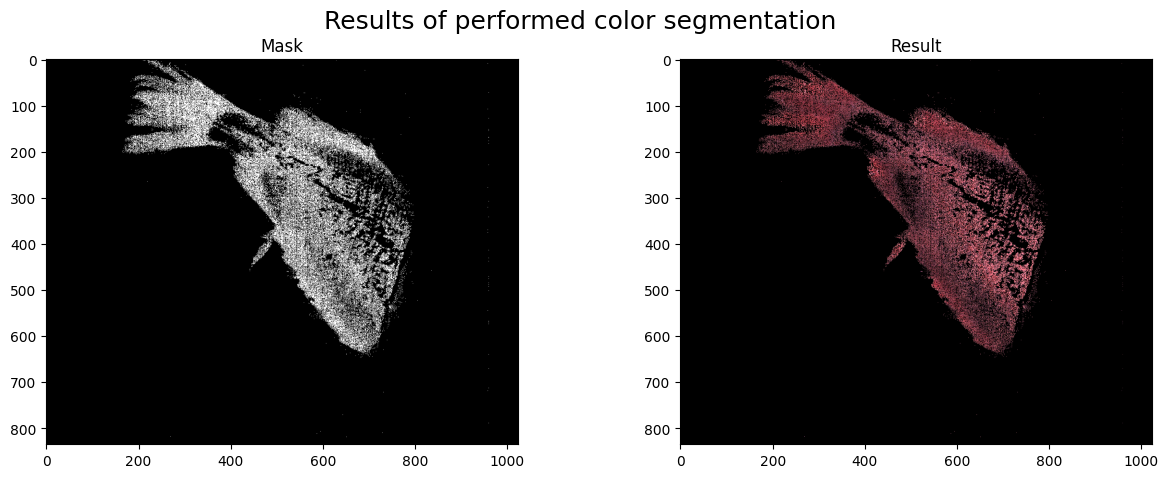

In [66]:
mask = color_segmentation(img_fish, LOWER_COLOR_FISH, UPPER_COLOR_FISH, True)

In [ ]:
def post_color_seg_filtering(img_rgb, img_gray, plot_result):
    """Performs filtering for better segmentation

    Args:
        img_rgb (_type_): Initial image (in RGB-format)
        img_gray (_type_): Image (in GRAY-format) to perform filtering on
        plot_result (_type_): Flag to plot results

    Returns:
        _type_: Resulting mask after filtering
    """

    kernel_dilation = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (8, 8))
    kernel_opening = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (8, 8))
    kernel_closing = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))

    dilation = cv2.dilate(img_gray, kernel_dilation, iterations = 1)
    opening = cv2.morphologyEx(dilation, cv2.MORPH_OPEN, kernel_opening)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel_closing)
    result = cv2.bitwise_and(img_rgb, img_rgb, mask=closing)

    if plot_result:
        fig, ax = plt.subplots(1, 5, figsize=(25, 5))

        fig.suptitle("Results of performed filtering after color segmentation", fontsize=18)

        ax[0].imshow(img_gray, cmap="gray")
        ax[0].set_title("Before filtering")

        ax[1].imshow(dilation, cmap="gray")
        ax[1].set_title("After dilation")

        ax[2].imshow(opening, cmap="gray")
        ax[2].set_title("After opening")

        ax[3].imshow(closing, cmap="gray")
        ax[3].set_title("After closing")

        ax[4].imshow(result)
        ax[4].set_title("Result")

    return closing

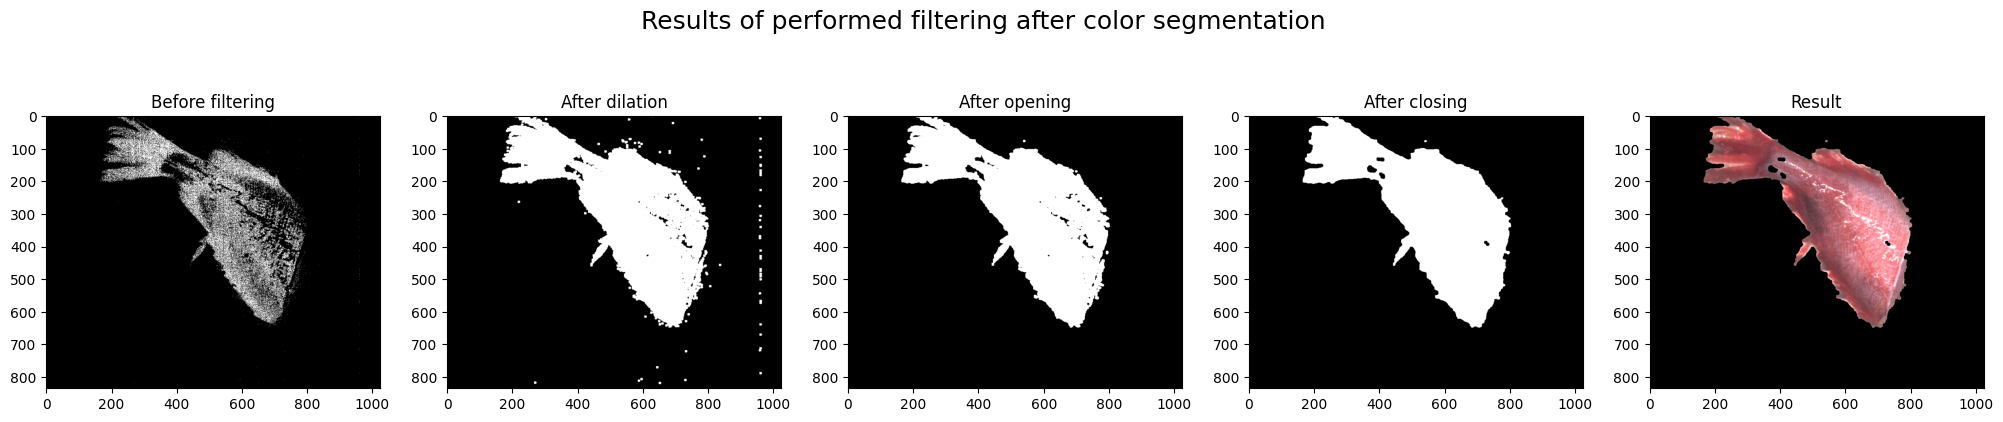

In [76]:
post_filtering = post_color_seg_filtering(img_fish, mask, True)

In [ ]:
def test_pipeline(test_set):
    for folder in test_set:
        for img_path in folder:
            img_fish = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

## Second method: Texture Segmentation

# Task 2: Shape Analysis

# Task 3: Tail Segmentation/Detection

# Task 4: Length Estimation

# Task 5: Subjective Evaluation/Conclusions

# Task 6: Annotation Tool

# Task 7: Synthetic Dataset

# Task 8: Fish segmentation using Yolov8